In [1]:
from cassini_upyp import UVIS_Observation
from pathlib import Path

In [2]:
datafolder = Path('./data')

datafiles = list(datafolder.iterdir())

print("Reading following files :")
for file in datafiles:
    print('>', file.name)

obs = UVIS_Observation(datafiles, prime_instrument='UVIS')

print('\nUVIS_Observation object created :',obs.name)
print(f' - Number of exposures : {obs.n_pics}')

Reading following files :
> FUV2006_015_19_11_PRIME.LBL
> FUV2006_015_15_51_PRIME.DAT
> FUV2006_015_17_59_PRIME.LBL
> FUV2006_015_16_55_PRIME.DAT
> FUV2006_015_14_47_PRIME.DAT
> FUV2006_015_14_47_PRIME.LBL
> FUV2006_015_16_55_PRIME.LBL
> FUV2006_015_19_11_PRIME.DAT
> FUV2006_015_15_51_PRIME.LBL
> FUV2006_015_17_59_PRIME.DAT
> FUV2006_015_19_03_PRIME.LBL
> FUV2006_015_19_03_PRIME.DAT

UVIS_Observation object created : FUV_2006_015_PRIME
 - Number of exposures : 69


In [3]:
# Compute geometry for all exposures
obs.set_geometry()

Computing geometry: 100%|██████████| 69/69 [00:09<00:00,  7.07it/s]


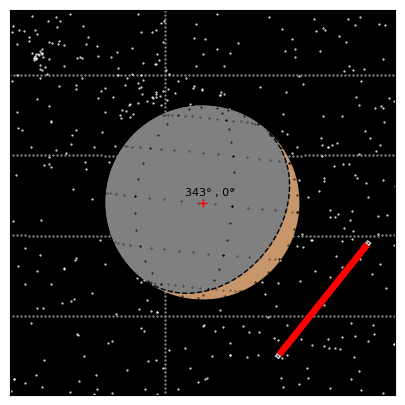

<Axes: >

In [4]:
%matplotlib inline
obs.geometry[0].plot(show=True)

In [ ]:
%matplotlib qt # Specific to notebook, to have interactive plots in a separate window with QT backend
obs.check_stars()

In [7]:
obs.set_background()

print('Background level:', obs.background_level, "counts/second")

Retrieving background... Done
Background level: 0.0004829915364583334 counts/second


In [9]:
obs.calibrate()

Applying calibration... Done


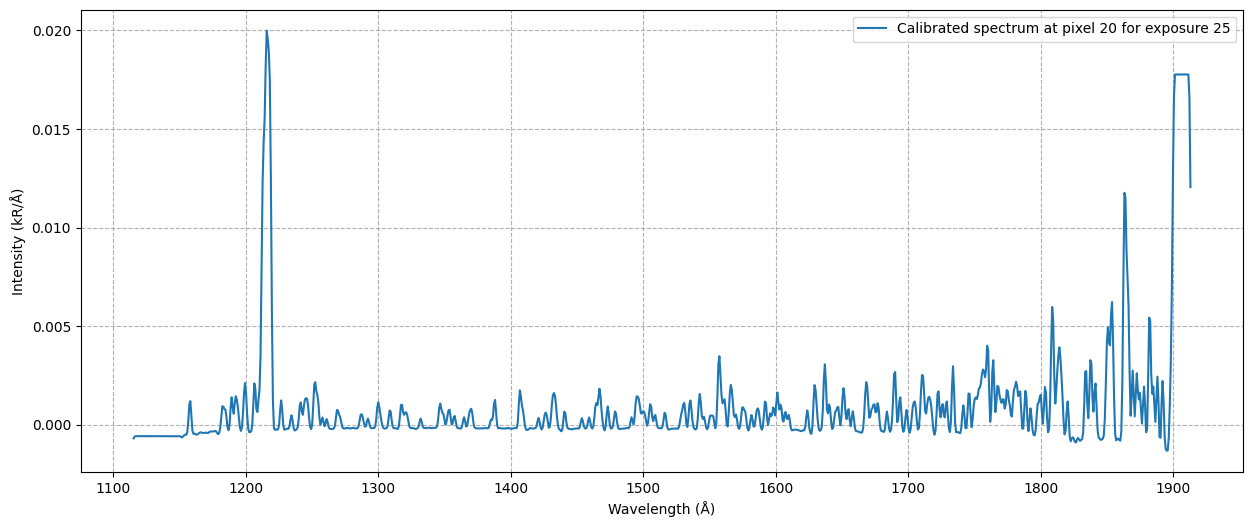

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(15,6))
plt.plot(obs.WL, obs.data[20,25], label='Calibrated spectrum at pixel 20 for exposure 25')

plt.xlabel('Wavelength (Å)')
plt.ylabel('Intensity (kR/Å)')

plt.grid(ls='--')
plt.legend()
plt.show()